# STUDI KASUS CLUSTERING DATA MINING – Mental Health Dataset

## Analisis Data Kesehatan Mental

**Framework:** CRISP-DM (Cross-Industry Standard Process for Data Mining)

---

# A. BUSINESS UNDERSTANDING

## Latar Belakang

Kesehatan mental merupakan salah satu aspek penting dalam kehidupan manusia yang dapat memengaruhi produktivitas, kualitas hidup, dan kesejahteraan seseorang. Berbagai faktor seperti stres, tekanan pekerjaan, gaya hidup, serta kondisi sosial dapat memengaruhi kesehatan mental individu.

Dengan meningkatnya perhatian terhadap isu kesehatan mental, diperlukan analisis data untuk memahami pola dan karakteristik kondisi mental seseorang. Melalui teknik data mining, data kesehatan mental dapat dikelompokkan berdasarkan karakteristik tertentu sehingga membantu dalam proses analisis dan pengambilan keputusan.

---

# 📊 Tujuan Pembelajaran

Setelah menyelesaikan studi kasus ini, peserta diharapkan mampu:

1. Menganalisis pola data kesehatan mental.
2. Memahami hubungan antar variabel yang memengaruhi kesehatan mental.
3. Membangun model clustering menggunakan algoritma K-Means.
4. Melakukan segmentasi data berdasarkan karakteristik tertentu.
5. Mengidentifikasi kelompok individu berdasarkan kondisi kesehatan mental.
6. Menghasilkan informasi yang dapat digunakan untuk mendukung pengambilan keputusan berbasis data.

---

# Manfaat Analisis Data

## 1. Mengetahui pola kesehatan mental

* Memahami karakteristik individu berdasarkan kondisi kesehatan mental yang dimiliki.

## 2. Menganalisis faktor yang memengaruhi kesehatan mental

* Mengetahui hubungan antara beberapa variabel dengan kondisi kesehatan mental seseorang.

## 3. Membantu segmentasi data

* Mengelompokkan individu berdasarkan karakteristik dan tingkat kesehatan mental.

## 4. Mendukung pengambilan keputusan berbasis data

* Hasil analisis dapat digunakan oleh peneliti, institusi pendidikan, maupun tenaga kesehatan.

## 5. Menjadi dasar pengembangan model machine learning

* Dataset dapat digunakan untuk clustering, klasifikasi, maupun prediksi kondisi kesehatan mental.

## 6. Membantu penelitian lebih lanjut

* Data dapat dimanfaatkan untuk pengembangan penelitian terkait kesehatan mental dan perilaku individu.


# B. DATA UNDERSTANDING

# SUMBER DATA

Dataset diperoleh dari Kaggle: https://www.kaggle.com/datasets/mahdimashayekhi/mental-health

Dataset: `mental_health_dataset.csv`

* Jumlah Baris : 10.000
* Jumlah Kolom : 14
* Format : CSV

---

# DESKRIPSI ATRIBUT

Dataset kesehatan mental digunakan untuk analisis clustering guna memahami pola dan karakteristik kondisi kesehatan mental individu.

| No | Nama Fitur             | Tipe Data   | Keterangan                       |
| -- | ---------------------- | ----------- | -------------------------------- |
| 1  | age                    | Integer     | Usia individu                    |
| 2  | gender                 | Kategorikal | Jenis kelamin individu           |
| 3  | employment_status      | Kategorikal | Status pekerjaan individu        |
| 4  | work_environment       | Kategorikal | Lingkungan kerja individu        |
| 5  | mental_health_history  | Kategorikal | Riwayat kesehatan mental         |
| 6  | seeks_treatment        | Kategorikal | Status mencari pengobatan/terapi |
| 7  | stress_level           | Integer     | Tingkat stres individu           |
| 8  | sleep_hours            | Float       | Rata-rata jam tidur              |
| 9  | physical_activity_days | Integer     | Jumlah hari aktivitas fisik      |
| 10 | depression_score       | Integer     | Skor tingkat depresi             |
| 11 | anxiety_score          | Integer     | Skor tingkat kecemasan           |
| 12 | social_support_score   | Integer     | Skor dukungan sosial             |
| 13 | productivity_score     | Integer     | Skor produktivitas individu      |
| 14 | mental_health_risk     | Kategorikal | Tingkat risiko kesehatan mental  |

---

# Catatan Penting

* Dataset digunakan untuk keperluan pembelajaran dan analisis data mining.
* Dataset berisi kombinasi data numerik dan kategorikal.
* Data dapat digunakan untuk proses clustering guna mengelompokkan individu berdasarkan kondisi kesehatan mental.

---

# Eksplorasi Data Awal

Hasil eksplorasi data awal menunjukkan bahwa:

- Tidak terdapat missing value yang signifikan.
- Dataset memiliki atribut numerik dan kategorikal.
- Variabel depresi, kecemasan, tingkat stres, dan produktivitas memiliki variasi nilai yang cukup besar.
- Korelasi antar variabel dapat digunakan sebagai dasar analisis clustering.
- Dataset siap untuk masuk ke tahap Data Preparation.


In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [4]:
df = pd.read_csv("mental_health_dataset.csv")

In [5]:
# Menampilkan seluruh dataset

df

,age,gender,employment_status,work_environment,mental_health_history,seeks_treatment,stress_level,sleep_hours,physical_activity_days,depression_score,anxiety_score,social_support_score,productivity_score,mental_health_risk
0,56,Male,Employed,On-site,Yes,Yes,6,6.2,3,28,17,54,59.7,High
1,46,Female,Student,On-site,No,Yes,10,9.0,4,30,11,85,54.9,High
2,32,Female,Employed,On-site,Yes,No,7,7.7,2,24,7,62,61.3,Medium
3,60,Non-binary,Self-employed,On-site,No,No,4,4.5,4,6,0,95,97.0,Low
4,25,Female,Self-employed,On-site,Yes,Yes,3,5.4,0,24,12,70,69.0,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,34,Female,Employed,On-site,Yes,Yes,5,6.1,3,9,21,8,90.0,Medium
9996,47,Male,Employed,On-site,Yes,No,1,5.7,3,5,12,45,90.8,Medium
9997,56,Female,Employed,On-site,Yes,No,1,8.3,0,1,18,7,99.2,Medium
9998,24,Male,Employed,On-site,Yes,Yes,9,6.1,0,28,21,32,56.7,High


In [6]:
# Jumlah baris dan kolom

print("Jumlah Baris :", df.shape[0])
print("Jumlah Kolom :", df.shape[1])

Jumlah Baris : 10000
Jumlah Kolom : 14


In [7]:
# Informasi tipe data

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     10000 non-null  int64  
 1   gender                  10000 non-null  object 
 2   employment_status       10000 non-null  object 
 3   work_environment        10000 non-null  object 
 4   mental_health_history   10000 non-null  object 
 5   seeks_treatment         10000 non-null  object 
 6   stress_level            10000 non-null  int64  
 7   sleep_hours             10000 non-null  float64
 8   physical_activity_days  10000 non-null  int64  
 9   depression_score        10000 non-null  int64  
 10  anxiety_score           10000 non-null  int64  
 11  social_support_score    10000 non-null  int64  
 12  productivity_score      10000 non-null  float64
 13  mental_health_risk      10000 non-null  object 
dtypes: float64(2), int64(6), object(6)
memo

In [8]:
# Statistik deskriptif

df.describe()

,age,stress_level,sleep_hours,physical_activity_days,depression_score,anxiety_score,social_support_score,productivity_score
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,41.557600,5.572000,6.473000,3.505700,15.039900,10.56180,50.117700,77.312210
std,13.749581,2.887741,1.473944,2.282737,8.990839,6.32264,29.229278,14.061202
min,18.000000,1.000000,3.000000,0.000000,0.000000,0.00000,0.000000,42.800000
25%,30.000000,3.000000,5.500000,2.000000,7.000000,5.00000,25.000000,65.800000
50%,41.500000,6.000000,6.500000,4.000000,15.000000,11.00000,50.000000,77.600000
75%,53.000000,8.000000,7.500000,5.000000,23.000000,16.00000,76.000000,89.200000
max,65.000000,10.000000,10.000000,7.000000,30.000000,21.00000,100.000000,100.000000


In [9]:
# Menampilkan seluruh atribut

print(df.columns.tolist())

['age', 'gender', 'employment_status', 'work_environment', 'mental_health_history', 'seeks_treatment', 'stress_level', 'sleep_hours', 'physical_activity_days', 'depression_score', 'anxiety_score', 'social_support_score', 'productivity_score', 'mental_health_risk']


In [10]:
# Mengecek nilai kosong

df.isnull().sum()

age                       0
gender                    0
employment_status         0
work_environment          0
mental_health_history     0
seeks_treatment           0
stress_level              0
sleep_hours               0
physical_activity_days    0
depression_score          0
anxiety_score             0
social_support_score      0
productivity_score        0
mental_health_risk        0
dtype: int64

In [11]:
# Mengecek data duplikat

print("Jumlah Data Duplikat :", df.duplicated().sum())

Jumlah Data Duplikat : 0


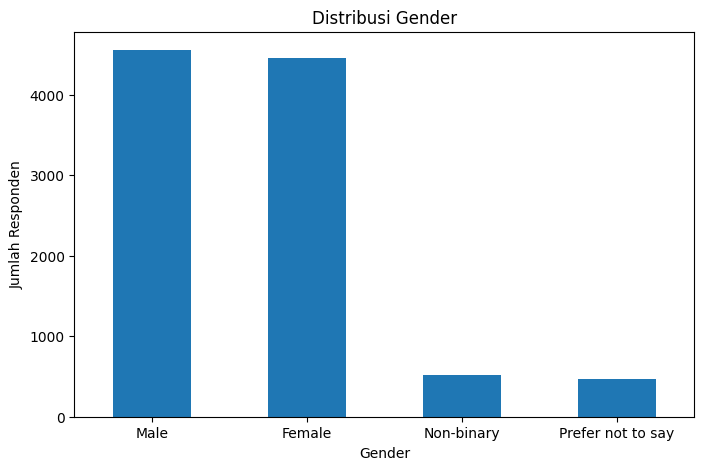

In [50]:
plt.figure(figsize=(8,5))

df['gender'].value_counts().plot(kind='bar')

plt.title('Distribusi Gender')
plt.xlabel('Gender')
plt.ylabel('Jumlah Responden')

plt.xticks(rotation=0)
plt.show()

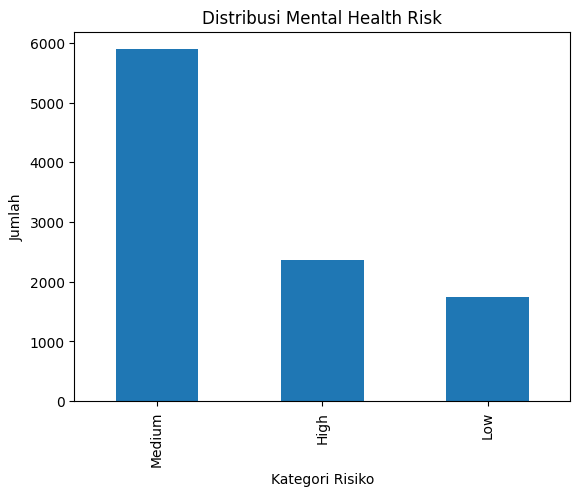

In [13]:
df['mental_health_risk'].value_counts().plot(
    kind='bar'
)

plt.title("Distribusi Mental Health Risk")
plt.xlabel("Kategori Risiko")
plt.ylabel("Jumlah")
plt.show()

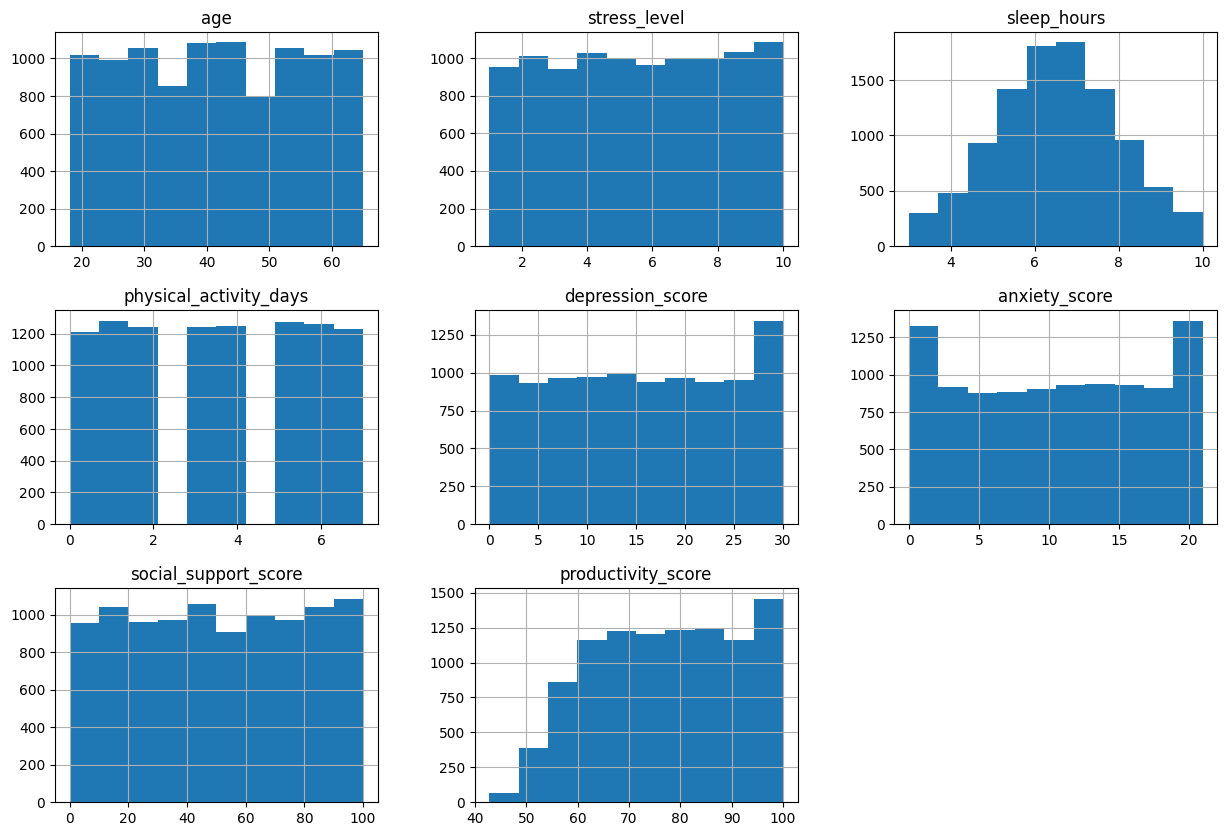

In [14]:
df.hist(
    figsize=(15,10)
)

plt.show()

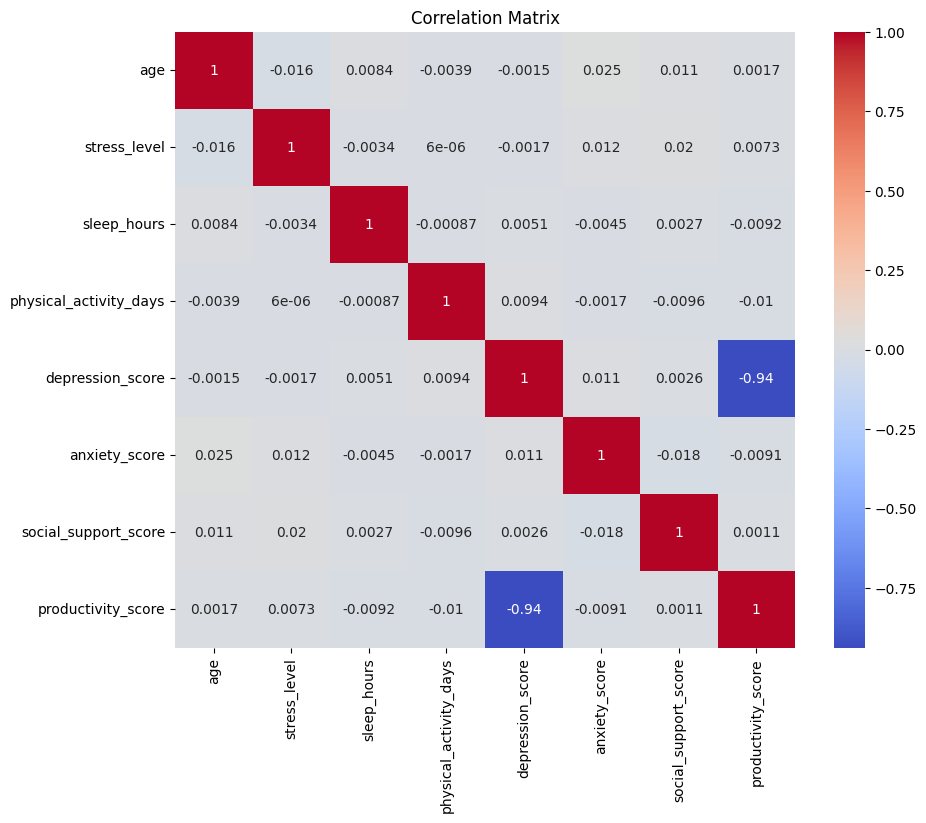

In [15]:
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include=['int64','float64']).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

# C. Data Preparation

Tahap Data Preparation dilakukan untuk mempersiapkan data agar siap digunakan dalam proses clustering menggunakan algoritma K-Means. Pada tahap ini dilakukan beberapa proses, yaitu data cleaning, handling missing values, encoding data, dan normalisasi data.

## 1. Data Cleaning

Data cleaning dilakukan untuk memastikan kualitas data yang digunakan dalam analisis. Proses ini meliputi:

- Pemeriksaan jumlah data dan tipe data pada setiap atribut.
- Pengecekan data duplikat.
- Pengecekan konsistensi nilai pada setiap atribut.
- Pengecekan missing value.

Hasil pemeriksaan menunjukkan bahwa data berada dalam kondisi yang baik dan siap untuk diproses lebih lanjut.

## 2. Handling Missing Values

Pengecekan missing value dilakukan menggunakan fungsi `isnull().sum()`.

Hasil pengecekan menunjukkan bahwa seluruh atribut memiliki nilai kosong (missing value) sebanyak 0, sehingga tidak diperlukan proses imputasi maupun penghapusan data.

## 3. Encoding Data

Karena algoritma K-Means hanya dapat mengolah data numerik, maka atribut kategorikal perlu dikonversi ke bentuk numerik menggunakan metode Label Encoding.

Atribut yang dilakukan encoding meliputi:

- gender
- employment_status
- work_environment
- mental_health_history
- seeks_treatment
- mental_health_risk

Proses encoding dilakukan menggunakan library `LabelEncoder` dari Scikit-Learn.

## 4. Seleksi Fitur

Tidak seluruh atribut digunakan dalam proses clustering. Fitur yang dipilih merupakan variabel yang berkaitan langsung dengan kondisi kesehatan mental, yaitu:

- age
- stress_level
- sleep_hours
- physical_activity_days
- depression_score
- anxiety_score
- social_support_score
- productivity_score

Fitur-fitur tersebut digunakan sebagai dasar pembentukan cluster.

## 5. Normalisasi Data

Data dinormalisasi menggunakan metode `StandardScaler`.

Normalisasi dilakukan karena setiap atribut memiliki rentang nilai yang berbeda. Dengan normalisasi, seluruh variabel berada pada skala yang sama sehingga tidak ada atribut yang mendominasi proses clustering.

Hasil normalisasi kemudian digunakan sebagai input pada tahap pemodelan menggunakan algoritma K-Means Clustering.

In [16]:
# Membuat salinan dataset
df_clean = df.copy()

In [17]:
# =====================================================
# 1. DATA CLEANING
# =====================================================

print("Jumlah Data Awal :", len(df_clean))
print("Jumlah Kolom :", df_clean.shape[1])

print("\nTipe Data:")
print(df_clean.dtypes)

Jumlah Data Awal : 10000
Jumlah Kolom : 14

Tipe Data:
age                         int64
gender                     object
employment_status          object
work_environment           object
mental_health_history      object
seeks_treatment            object
stress_level                int64
sleep_hours               float64
physical_activity_days      int64
depression_score            int64
anxiety_score               int64
social_support_score        int64
productivity_score        float64
mental_health_risk         object
dtype: object


In [18]:
# =====================================================
# 3. CEK DATA DUPLIKAT
# =====================================================

print("\nJumlah Data Duplikat :", df_clean.duplicated().sum())

# Tidak menghapus data agar seluruh 10.000 data tetap digunakan

print("\nJumlah Data Setelah Pengecekan :", len(df_clean))


Jumlah Data Duplikat : 0

Jumlah Data Setelah Pengecekan : 10000


In [19]:
# =====================================================
# 2. HANDLING MISSING VALUE
# =====================================================

print("\nJumlah Missing Value:")
print(df_clean.isnull().sum())

# Total Missing Value
print("\nTotal Missing Value :", df_clean.isnull().sum().sum())



Jumlah Missing Value:
age                       0
gender                    0
employment_status         0
work_environment          0
mental_health_history     0
seeks_treatment           0
stress_level              0
sleep_hours               0
physical_activity_days    0
depression_score          0
anxiety_score             0
social_support_score      0
productivity_score        0
mental_health_risk        0
dtype: int64

Total Missing Value : 0


In [20]:
# =====================================================
# ENCODING DATA KATEGORIKAL
# =====================================================

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = [
    'gender',
    'employment_status',
    'work_environment',
    'mental_health_history',
    'seeks_treatment',
    'mental_health_risk'
]

for col in categorical_columns:
    df_clean[col] = le.fit_transform(df_clean[col])

print("Encoding berhasil dilakukan")

Encoding berhasil dilakukan


In [21]:
# Menampilkan seluruh data setelah encoding

display(df_clean)

print("\nJumlah Data :", len(df_clean))

,age,gender,employment_status,work_environment,mental_health_history,seeks_treatment,stress_level,sleep_hours,physical_activity_days,depression_score,anxiety_score,social_support_score,productivity_score,mental_health_risk
0,56,1,0,1,1,1,6,6.2,3,28,17,54,59.7,0
1,46,0,2,1,0,1,10,9.0,4,30,11,85,54.9,0
2,32,0,0,1,1,0,7,7.7,2,24,7,62,61.3,2
3,60,2,1,1,0,0,4,4.5,4,6,0,95,97.0,1
4,25,0,1,1,1,1,3,5.4,0,24,12,70,69.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,34,0,0,1,1,1,5,6.1,3,9,21,8,90.0,2
9996,47,1,0,1,1,0,1,5.7,3,5,12,45,90.8,2
9997,56,0,0,1,1,0,1,8.3,0,1,18,7,99.2,2
9998,24,1,0,1,1,1,9,6.1,0,28,21,32,56.7,0



Jumlah Data : 10000


In [22]:
# =====================================================
# SELEKSI FITUR
# =====================================================

features = [
    'age',
    'stress_level',
    'sleep_hours',
    'physical_activity_days',
    'depression_score',
    'anxiety_score',
    'social_support_score',
    'productivity_score'
]

X = df_clean[features]

print("Jumlah Data :", X.shape[0])
print("Jumlah Fitur :", X.shape[1])

display(X)

Jumlah Data : 10000
Jumlah Fitur : 8


,age,stress_level,sleep_hours,physical_activity_days,depression_score,anxiety_score,social_support_score,productivity_score
0,56,6,6.2,3,28,17,54,59.7
1,46,10,9.0,4,30,11,85,54.9
2,32,7,7.7,2,24,7,62,61.3
3,60,4,4.5,4,6,0,95,97.0
4,25,3,5.4,0,24,12,70,69.0
...,...,...,...,...,...,...,...,...
9995,34,5,6.1,3,9,21,8,90.0
9996,47,1,5.7,3,5,12,45,90.8
9997,56,1,8.3,0,1,18,7,99.2
9998,24,9,6.1,0,28,21,32,56.7


In [23]:
# =====================================================
# NORMALISASI DATA
# =====================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [24]:
# Mengubah hasil scaling menjadi DataFrame

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=features
)

display(X_scaled_df)

print("Jumlah Data Setelah Normalisasi :", X_scaled_df.shape[0])
print("Jumlah Fitur Setelah Normalisasi :", X_scaled_df.shape[1])

,age,stress_level,sleep_hours,physical_activity_days,depression_score,anxiety_score,social_support_score,productivity_score
0,1.050441,0.148220,-0.185227,-0.221543,1.441550,1.018328,0.132829,-1.252602
1,0.323110,1.533455,1.714534,0.216549,1.664010,0.069310,1.193462,-1.593984
2,-0.695154,0.494529,0.832502,-0.659636,0.996631,-0.563369,0.406541,-1.138808
3,1.341373,-0.544397,-1.338653,0.216549,-1.005507,-1.670557,1.535602,1.400220
4,-1.204286,-0.890706,-0.728015,-1.535821,0.996631,0.227480,0.680253,-0.591175
...,...,...,...,...,...,...,...,...
9995,-0.549688,-0.198089,-0.253075,-0.221543,-0.671817,1.651007,-1.441014,0.902371
9996,0.395843,-1.583323,-0.524470,-0.221543,-1.116737,0.227480,-0.175097,0.959268
9997,1.050441,-1.583323,1.239594,-1.535821,-1.561656,1.176498,-1.475228,1.556687
9998,-1.277019,1.187146,-0.253075,-1.535821,1.441550,1.651007,-0.619879,-1.465966


Jumlah Data Setelah Normalisasi : 10000
Jumlah Fitur Setelah Normalisasi : 8


# D. Modeling

Pada tahap modeling dilakukan proses pengelompokan data kesehatan mental menggunakan algoritma K-Means Clustering.

## 1. Pemilihan Algoritma

Algoritma yang digunakan pada penelitian ini adalah K-Means Clustering. Algoritma ini dipilih karena mampu mengelompokkan data berdasarkan kemiripan karakteristik antar data.

Proses clustering dilakukan menggunakan beberapa variabel numerik, yaitu:

* age
* stress_level
* sleep_hours
* physical_activity_days
* depression_score
* anxiety_score
* social_support_score
* productivity_score

## 2. Proses clustering

Model K-Means dilatih menggunakan data yang telah melalui tahap normalisasi menggunakan StandardScaler.

Tahapan proses training meliputi:

* membangun model K-Means,
* menentukan jumlah cluster,
* melakukan proses fit terhadap data,
* menghasilkan label cluster pada setiap data.

Hasil proses training menghasilkan 3 kelompok individu dengan karakteristik kesehatan mental yang berbeda-beda.

## 3. Hasil Clustering

Hasil clustering kemudian ditambahkan ke dalam dataset pada kolom Cluster untuk mengetahui kelompok dari masing-masing data.

Visualisasi cluster dilakukan menggunakan scatterplot untuk melihat persebaran data antar cluster.


In [54]:
# =====================================================
# D. MODELING
# =====================================================

from sklearn.cluster import KMeans

# Variabel yang digunakan untuk clustering
features = [
    'age',
    'stress_level',
    'sleep_hours',
    'physical_activity_days',
    'depression_score',
    'anxiety_score',
    'social_support_score',
    'productivity_score'
]

# Mengambil data fitur
X = df_clean[features]

In [53]:
# =====================================================
# MEMBANGUN MODEL K-MEANS
# =====================================================

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Melatih model
kmeans.fit(X_scaled)


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [55]:
# =====================================================
# MENAMBAHKAN LABEL CLUSTER
# =====================================================

df_clean['Cluster'] = kmeans.labels_

# Menampilkan hasil clustering
display(df_clean)

print("Jumlah Data :", len(df_clean))

,age,gender,employment_status,work_environment,mental_health_history,seeks_treatment,stress_level,sleep_hours,physical_activity_days,depression_score,anxiety_score,social_support_score,productivity_score,mental_health_risk,Cluster
0,56,1,0,1,1,1,6,6.2,3,28,17,54,59.7,0,0
1,46,0,2,1,0,1,10,9.0,4,30,11,85,54.9,0,0
2,32,0,0,1,1,0,7,7.7,2,24,7,62,61.3,2,0
3,60,2,1,1,0,0,4,4.5,4,6,0,95,97.0,1,2
4,25,0,1,1,1,1,3,5.4,0,24,12,70,69.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,34,0,0,1,1,1,5,6.1,3,9,21,8,90.0,2,1
9996,47,1,0,1,1,0,1,5.7,3,5,12,45,90.8,2,1
9997,56,0,0,1,1,0,1,8.3,0,1,18,7,99.2,2,1
9998,24,1,0,1,1,1,9,6.1,0,28,21,32,56.7,0,0


Jumlah Data : 10000


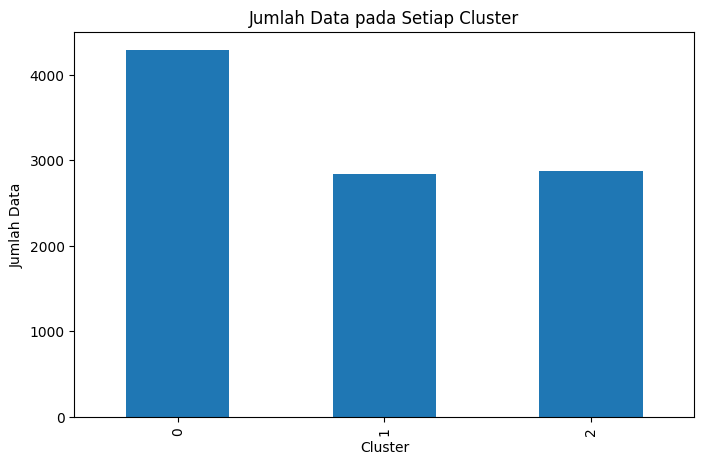

In [34]:
plt.figure(figsize=(8,5))

df_clean['Cluster'].value_counts().sort_index().plot(
    kind='bar'
)

plt.title('Jumlah Data pada Setiap Cluster')
plt.xlabel('Cluster')
plt.ylabel('Jumlah Data')

plt.show()

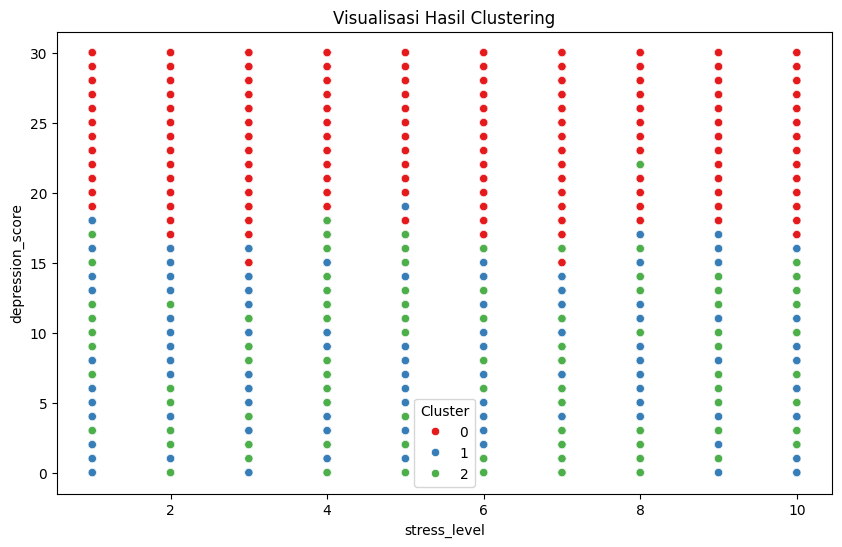

In [35]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_clean,
    x='stress_level',
    y='depression_score',
    hue='Cluster',
    palette='Set1'
)

plt.title('Visualisasi Hasil Clustering')
plt.show()

In [36]:
centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=features
)

centroids

,age,stress_level,sleep_hours,physical_activity_days,depression_score,anxiety_score,social_support_score,productivity_score
0,0.005311,0.018687,0.004484,0.022874,0.971279,0.025224,-0.012877,-0.963844
1,0.019274,-0.073876,-0.027534,0.031351,-0.749024,0.066025,-0.897926,0.737040
2,-0.027039,0.045221,0.020567,-0.065278,-0.711221,-0.103144,0.908740,0.711968


# E. Evaluation

Tahap evaluasi dilakukan untuk mengukur kualitas hasil clustering yang dihasilkan oleh algoritma K-Means.

## 1. Hasil Evaluasi Model

Evaluasi model dilakukan menggunakan dua metrik, yaitu:

* **Silhouette Score**, untuk mengukur tingkat kemiripan data dalam satu cluster dibandingkan dengan cluster lainnya.
* **Davies-Bouldin Index (DBI)**, untuk mengukur kualitas pemisahan antar cluster.

Hasil evaluasi menunjukkan nilai Silhouette Score sebesar **(isi sesuai output notebook)** dan nilai Davies-Bouldin Index sebesar **(isi sesuai output notebook)**.

## 2. Tingkat Performa Model

Tingkat performa model dihitung berdasarkan nilai Silhouette Score dengan rumus:

Performa Model = Silhouette Score × 100%

Semakin mendekati nilai 100%, maka kualitas cluster yang terbentuk semakin baik.

## 3. Kriteria Keberhasilan

Kriteria keberhasilan model ditetapkan sebesar **80%**.

* Jika performa model ≥ 80%, maka model dinyatakan berhasil.
* Jika performa model < 80%, maka model dinyatakan belum memenuhi target evaluasi.

Berdasarkan hasil evaluasi yang diperoleh, model dinilai **(berhasil/belum berhasil sesuai output)** dalam mengelompokkan data kesehatan mental menggunakan algoritma K-Means Clustering.


In [41]:
# =====================================================
# E. EVALUATION
# =====================================================

from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score

# Menghitung Silhouette Score
silhouette = silhouette_score(X_scaled, kmeans.labels_)

# Menghitung Davies-Bouldin Index
dbi = davies_bouldin_score(X_scaled, kmeans.labels_)

print("Silhouette Score :", round(silhouette, 4))
print("Davies-Bouldin Index :", round(dbi, 4))

Silhouette Score : 0.123
Davies-Bouldin Index : 2.3834


In [42]:
# Mengubah Silhouette Score menjadi persentase

performa = silhouette * 100

print("Performa Model :", round(performa, 2), "%")

Performa Model : 12.3 %


In [43]:
if performa >= 80:
    print("Status : BERHASIL")
else:
    print("Status : BELUM MEMENUHI TARGET 80%")

Status : BELUM MEMENUHI TARGET 80%


In [44]:
print("="*50)
print("HASIL EVALUASI MODEL")
print("="*50)

print("Silhouette Score      :", round(silhouette,4))
print("Davies-Bouldin Index  :", round(dbi,4))
print("Performa Model        :", round(performa,2), "%")

if performa >= 80:
    print("Status Evaluasi       : BERHASIL")
else:
    print("Status Evaluasi       : BELUM MEMENUHI TARGET")

HASIL EVALUASI MODEL
Silhouette Score      : 0.123
Davies-Bouldin Index  : 2.3834
Performa Model        : 12.3 %
Status Evaluasi       : BELUM MEMENUHI TARGET


# F. Deployment

Tahap deployment merupakan tahap akhir dalam framework CRISP-DM. Pada tahap ini hasil clustering yang telah diperoleh disimpan dan disajikan dalam bentuk yang dapat digunakan untuk analisis lebih lanjut.

## 1. Penyimpanan Hasil Clustering

Hasil clustering disimpan ke dalam file `hasil_clustering_kesehatan_mental.csv` yang berisi seluruh data beserta label cluster yang dihasilkan oleh algoritma K-Means.

## 2. Penyajian Hasil

Dataset hasil clustering menampilkan kelompok (cluster) dari setiap individu berdasarkan karakteristik kesehatan mental yang dimiliki.

Selain itu, dibuat ringkasan karakteristik setiap cluster yang berisi rata-rata nilai variabel:

- age
- stress_level
- sleep_hours
- physical_activity_days
- depression_score
- anxiety_score
- social_support_score
- productivity_score

## 3. Implementasi

Hasil clustering dapat digunakan sebagai dasar dalam:

- Identifikasi kelompok kesehatan mental.
- Analisis karakteristik individu pada setiap cluster.
- Pengambilan keputusan terkait program kesehatan mental.
- Pengembangan dashboard atau website visualisasi data.

Dengan demikian, proses CRISP-DM telah berhasil diselesaikan mulai dari Business Understanding, Data Understanding, Data Preparation, Modeling, Evaluation, hingga Deployment.

In [45]:
# =====================================================
# F. DEPLOYMENT
# =====================================================

df_clean.to_csv(
    'hasil_clustering_kesehatan_mental.csv',
    index=False
)

print("File berhasil disimpan")

File berhasil disimpan


In [46]:
# Menampilkan hasil akhir

df_clean.head(10)

,age,gender,employment_status,work_environment,mental_health_history,seeks_treatment,stress_level,sleep_hours,physical_activity_days,depression_score,anxiety_score,social_support_score,productivity_score,mental_health_risk,Cluster
0,56,1,0,1,1,1,6,6.2,3,28,17,54,59.7,0,0
1,46,0,2,1,0,1,10,9.0,4,30,11,85,54.9,0,0
2,32,0,0,1,1,0,7,7.7,2,24,7,62,61.3,2,0
3,60,2,1,1,0,0,4,4.5,4,6,0,95,97.0,1,2
4,25,0,1,1,1,1,3,5.4,0,24,12,70,69.0,0,0
5,38,0,3,1,1,1,3,9.9,3,17,9,63,69.3,2,0
6,56,2,0,2,0,1,2,5.5,1,25,3,87,63.1,2,0
7,36,1,2,2,0,0,8,7.1,5,25,8,72,58.4,2,0
8,40,1,0,0,0,0,7,6.5,6,28,6,46,60.4,2,0
9,28,0,0,2,0,0,8,3.1,0,7,18,88,93.2,2,2


In [47]:
cluster_result = df_clean['Cluster'].value_counts().sort_index()

print(cluster_result)

Cluster
0    4289
1    2841
2    2870
Name: count, dtype: int64


In [48]:
display(df_clean)

print("Jumlah Data :", len(df_clean))

,age,gender,employment_status,work_environment,mental_health_history,seeks_treatment,stress_level,sleep_hours,physical_activity_days,depression_score,anxiety_score,social_support_score,productivity_score,mental_health_risk,Cluster
0,56,1,0,1,1,1,6,6.2,3,28,17,54,59.7,0,0
1,46,0,2,1,0,1,10,9.0,4,30,11,85,54.9,0,0
2,32,0,0,1,1,0,7,7.7,2,24,7,62,61.3,2,0
3,60,2,1,1,0,0,4,4.5,4,6,0,95,97.0,1,2
4,25,0,1,1,1,1,3,5.4,0,24,12,70,69.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,34,0,0,1,1,1,5,6.1,3,9,21,8,90.0,2,1
9996,47,1,0,1,1,0,1,5.7,3,5,12,45,90.8,2,1
9997,56,0,0,1,1,0,1,8.3,0,1,18,7,99.2,2,1
9998,24,1,0,1,1,1,9,6.1,0,28,21,32,56.7,0,0


Jumlah Data : 10000


In [49]:
cluster_summary = df_clean.groupby('Cluster')[
    [
        'age',
        'stress_level',
        'sleep_hours',
        'physical_activity_days',
        'depression_score',
        'anxiety_score',
        'social_support_score',
        'productivity_score'
    ]
].mean()

cluster_summary.to_csv(
    'ringkasan_cluster.csv'
)

cluster_summary

,age,stress_level,sleep_hours,physical_activity_days,depression_score,anxiety_score,social_support_score,productivity_score
Cluster,,,,,,,,
0,41.639077,5.626253,6.479482,3.557239,23.776638,10.720914,49.730940,63.757100
1,41.837381,5.361844,6.435234,3.575150,8.306934,10.978177,23.868356,87.675009
2,41.158885,5.698955,6.500697,3.359930,8.648432,9.911847,76.679791,87.311220


In [56]:
import joblib

joblib.dump(kmeans, "model_kmeans.pkl")

['model_kmeans.pkl']